## Fraud detection [Cont.]
**Task is apply different algo. like (bagging, boosting, stacking) and finding the best classification model.**

In [1]:
# import necessary lib's 

import numpy as np
import pandas as pd

### Loading dataset

In [2]:
FILE_PATH=r"E:\45DaysML\projects\Fraud-detection\dataset\preprocessed\updated_dataset001.csv"
chunk_size=100_000
results = []

with pd.read_csv(FILE_PATH, chunksize=chunk_size) as raw_dataset:
    for chunk in raw_dataset:
        results.append(chunk)

df = pd.concat(results, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)

### Columns in the dataframe includes

In [3]:
print(df.columns)

Index(['step', 'type', 'amount', 'isFraud', 'sender_balance_difference',
       'receiver_balance_difference', 'amount_over_sender',
       'amount_over_receiver', 'is_large_transaction'],
      dtype='object')


### Filter training and testing columns

In [4]:
X, y = df[[ col for col in df.columns if col != 'isFraud']], df[['isFraud']]
X.shape, y.shape

((6362620, 8), (6362620, 1))

In [5]:
X.columns

Index(['step', 'type', 'amount', 'sender_balance_difference',
       'receiver_balance_difference', 'amount_over_sender',
       'amount_over_receiver', 'is_large_transaction'],
      dtype='object')

### Performing encoding on categorical columns
We've done all the required pre-preprocessing in the previous steps, now it's the final step of **Encoding** of *categorical* column and **Scaling** of each column. Here, only the `type` is the categorical column rest all are numerical, therefore we need to perform `OneHotEncoding` only on this column.

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [7]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 8 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   step                         int64  
 1   type                         object 
 2   amount                       float64
 3   sender_balance_difference    float64
 4   receiver_balance_difference  float64
 5   amount_over_sender           float64
 6   amount_over_receiver         float64
 7   is_large_transaction         int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 388.3+ MB


In [8]:
X_numeric = X.select_dtypes(include=['int64', 'float64'])
X_categorical = X.select_dtypes(include=['object'])

In [9]:
transform = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(), X_categorical.columns),
        ('scaler', StandardScaler(), X_numeric.columns),
    ],
)

X_final = transform.fit_transform(X)

In [10]:
X_final.shape

(6362620, 12)

### Splitting dataset for training and testing

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_final, y.values,
                                                    test_size=0.3,
                                                    stratify=y)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((4453834, 12), (4453834, 1), (1908786, 12), (1908786, 1))

### Calculating class weights

In [12]:
from sklearn.utils.class_weight import compute_class_weight

classes=np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train.ravel(),
)

class_weight_dict = dict(zip(classes, weights))
print(class_weight_dict)

{0: 0.5006462331542675, 1: 387.35727952687427}


### Bagging algo.

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, classification_report

In [14]:
random_forest_classifier = RandomForestClassifier(class_weight=class_weight_dict, n_estimators=300,
                                                  n_jobs=-1,
                                                  max_depth=7,)
random_forest_classifier.fit(X_train, y_train)

C:\Users\papsr\anaconda3\envs\dl\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,300
,criterion,'gini'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
predictions_random_forest_classifier = random_forest_classifier.predict(X_test)

In [16]:
print(classification_report(y_test, predictions_random_forest_classifier))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.82      0.99      0.90      2464

    accuracy                           1.00   1908786
   macro avg       0.91      1.00      0.95   1908786
weighted avg       1.00      1.00      1.00   1908786



In [17]:
print(confusion_matrix(y_test, predictions_random_forest_classifier))

[[1905772     550]
 [     13    2451]]


### Boosting algo.

In [18]:
from xgboost import XGBClassifier

In [19]:
xgb_classifier = XGBClassifier(n_estimators=300,
                               n_jobs=-1,
                               objective="binary:logistic",
                               max_depth=7,
                               learning_rate=1e-2)

xgb_classifier.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [20]:
predictions_xgb_classifier = xgb_classifier.predict(X_test)

In [21]:
print(classification_report(y_test, predictions_xgb_classifier))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.94      0.88      0.91      2464

    accuracy                           1.00   1908786
   macro avg       0.97      0.94      0.95   1908786
weighted avg       1.00      1.00      1.00   1908786



In [22]:
print(confusion_matrix(y_test, predictions_xgb_classifier))

[[1906190     132]
 [    307    2157]]


From the above results, we can clearly see that the **Bagging** performs better than **Boosting**, Although both are above to achieve the `100%` accuracy but the difference in the `precision` and `recall`.
<br/>
In the case of **Bagging** we can clearly see higher `recall` score than **Boosting**. This can also be shown from the confusion matrix, where bagging_confusion_matrix[1][0](13),  shows lower value than the boosting_confusion_matrix[1][0] (307).

### Plotting ROC-AUC curves for both the algo.

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

In [24]:
proba_random_forest_classifier = random_forest_classifier.predict_proba(X_test)[:, 1]
proba_xgb_classifier = xgb_classifier.predict_proba(X_test)[:, 1]

In [27]:
fpr_random_forest_classifier, tpr_random_forest_classifier, _ = roc_curve(y_test, proba_random_forest_classifier)
auc_random_forest_classifier = roc_auc_score(y_test, proba_random_forest_classifier)

fpr_xgb_classifier, tpr_xgb_classifier, _ = roc_curve(y_test, proba_xgb_classifier)
auc_xgb_classifier = roc_auc_score(y_test, proba_xgb_classifier)

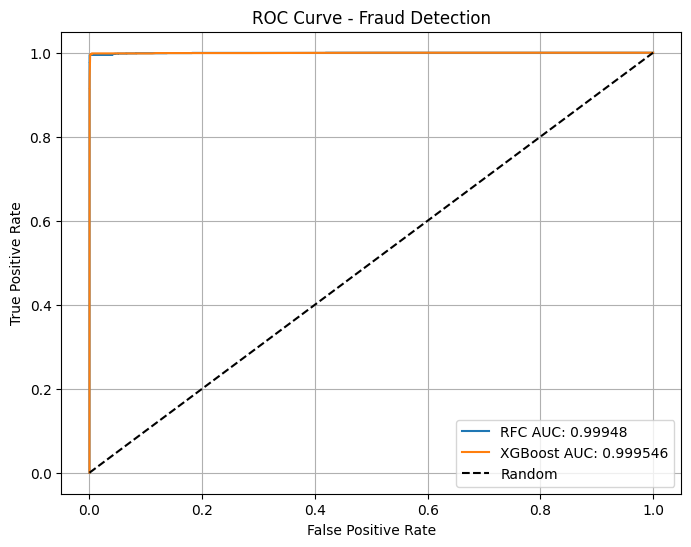

In [30]:
plt.figure(figsize=(8,6))
plt.plot(fpr_random_forest_classifier, tpr_random_forest_classifier, label=f"RFC AUC: {auc_random_forest_classifier:.5f}")
plt.plot(fpr_xgb_classifier, tpr_xgb_classifier, label=f"XGBoost AUC: {auc_xgb_classifier:5f}")

plt.plot([0,1], [0,1], 'k--', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Fraud Detection')
plt.legend()
plt.grid(True)
plt.show()